# 02 — Feature Engineering

Build the design matrix from `merged_books.csv`. All features use only
information available at or before the book's publication date.

**Input:** `data/merged_books.csv`

**Output:** `data/features.parquet` (primary — preserves dtypes) and
`data/features.csv` 

## Feature plan

| Group | Columns | Notes |
|-------|---------|-------|
| Title structure | `title_word_count`, `has_subtitle`, `is_series` | `title_char_count` also computed but dropped in Section 9 — r=0.966 with `title_word_count` |
| Page count | `log_pages` | log1p; NaN left as-is, imputed later inside the model pipeline (train split only) |
| Publication decade | `pub_decade` | numeric (1930, 1940, ...), not one-hot |
| Genre | `genre_*` (top 20 one-hot), `genre_count` | overlapping tags expected (e.g. suspense/thriller r=0.79) — kept, not pruned, since they're distinct concepts, not duplicate measurements |
| Author prior NYT | `author_prior_nyt_count` | prior hits strictly BEFORE pub_year; same-year publications excluded from each other's count |
| Author publishing gap | `years_since_last_pub`, `is_debut` | NaN for debut authors is structural (no "true" value exists), not observational missingness — always keep `is_debut` alongside the numeric column |
| Author credits | `num_credits`, `has_multiple_credits` | GoodBooks bundles co-authors/translators/illustrators together; ~18.8% of books have multiple credits |
| Description length | `description_word_count` | word count, 0 for missing |
| Description sentiment | `desc_neg/neu/pos/compound` | VADER; explored in Section 6 but NOT included in the saved structural matrix — added later in `04` via `build_all_features()`, per `03`'s "structural only" baseline design |
| Description embeddings | (not built here) | `build_all_features(include_embeddings=True)`, used only in `04` |

**Leakage safeguards** (`build_features.py`): `LEAKAGE_COLS` (ratings/`books_count`
— post-outcome popularity proxies), `ID_COLS` (pure identifiers, no signal),
`TARGET_LEAKAGE_COLS` (`nyt_title`/`weeks_on_list`/etc. — directly encode
match/outcome). `build_structural_features()` asserts none of these leak into
the output. Description text is also scrubbed of accolade language
("bestseller", "New York Times", etc.) before sentiment/embedding, since
publisher blurbs sometimes get updated post-success.

**Redundancy handling:** correlation heatmap in Section 8; only pairs with
|r| ≥ 0.9 are dropped (Section 9) — high but *expected* overlaps (genre
families, `pub_decade`/`classics`) are kept deliberately.

In [1]:
# !pip install vaderSentiment

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

# from utils.paths import derived_path
from features.build_features import (
    title_features,
    page_count_feature,
    publication_decade,
    genre_dummies,
    genre_count,
    author_prior_nyt_count,
    years_since_last_pub,
    author_credit_count,
    description_length,
    description_sentiment,
    description_embeddings,
    build_structural_features,
    drop_correlated_features,
)

DATA_PATH = Path('..') / 'data' / 'merged_books.csv'
df = pd.read_csv(DATA_PATH)
print(df.shape)

(7983, 46)


## 1. Title structure

In [3]:
# Implement title_features(df) and inspect


tf = title_features(df)
print(tf.describe(include='all'))
print()
print('has_subtitle rate:', tf['has_subtitle'].mean())
print('is_series rate:', tf['is_series'].mean())
print('word count median:', tf['title_word_count'].median())

        title_word_count  title_char_count has_subtitle is_series
count        7983.000000       7983.000000         7983      7983
unique               NaN               NaN            2         2
top                  NaN               NaN        False      True
freq                 NaN               NaN         7474      4235
mean            3.279469         18.108606          NaN       NaN
std             2.160426         11.864963          NaN       NaN
min             1.000000          1.000000          NaN       NaN
25%             2.000000         11.000000          NaN       NaN
50%             3.000000         16.000000          NaN       NaN
75%             4.000000         21.000000          NaN       NaN
max            33.000000        174.000000          NaN       NaN

has_subtitle rate: 0.06376049104346737
is_series rate: 0.5305023174245271
word count median: 3.0


## 2. Page count

In [4]:
# Implement page_count_feature(df)
# Check missing rate; impute at median WITHIN the training split, not globally

pages_feat = page_count_feature(df)
print(f'Missing rate: {pages_feat.isna().mean()*100:.2f}%')
print(pages_feat.describe())

Missing rate: 0.81%
count    7918.000000
mean        5.722991
std         0.643209
min         0.000000
25%         5.556828
50%         5.840642
75%         6.049143
max         8.136811
Name: log_pages, dtype: float64


## 3. Publication decade

In [5]:
# Implement publication_decade(df)
# This should be a numeric feature (1990, 2000, …) not one-hot;
# the model should learn that recency matters monotonically

decade_feat = publication_decade(df)
print(decade_feat.value_counts().sort_index())

pub_year
1930      95
1940     123
1950     177
1960     216
1970     325
1980     591
1990    1112
2000    2605
2010    2723
Name: count, dtype: Int64


## 4. Genre

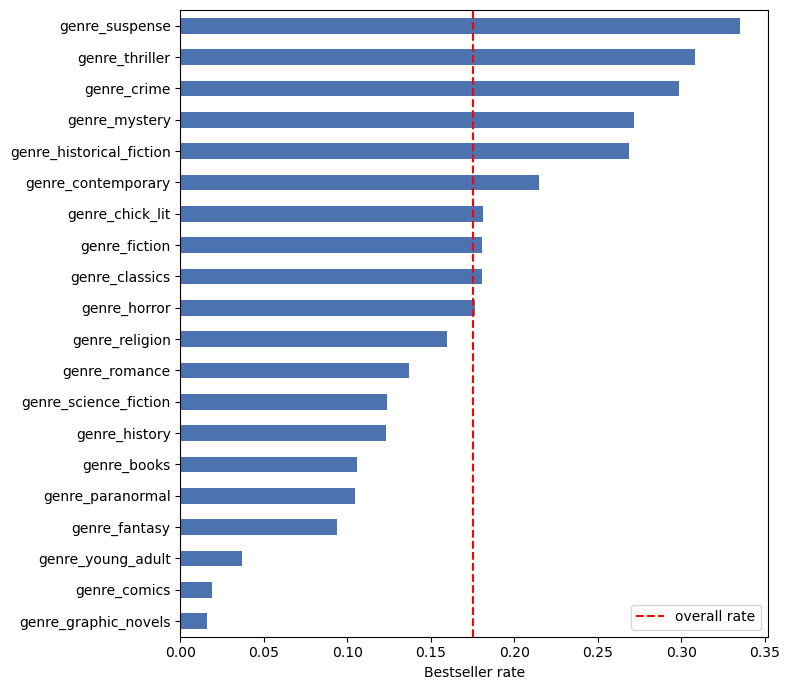

count    7983.000000
mean        4.795190
std         1.813123
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        14.000000
Name: genre_count, dtype: float64


In [6]:
# Implement genre_dummies(df, top_n=20) and genre_count(df)
# Plot bestseller rate per genre to check signal before encoding

genres_df = genre_dummies(df, top_n=20)
genre_ct  = genre_count(df)

# Plot bestseller rate per genre — check signal before committing to these 20
rates = {}
for col in genres_df.columns:
    rates[col] = df.loc[genres_df[col], 'nyt_bestseller'].mean()
rates = pd.Series(rates).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
rates.plot(kind='barh', ax=ax, color='#4C72B0')
ax.axvline(df['nyt_bestseller'].mean(), color='red', linestyle='--', label='overall rate')
ax.set_xlabel('Bestseller rate')
ax.legend()
plt.tight_layout()
plt.show()

print(genre_ct.describe())

## 5. Author prior NYT count

This is the trickiest feature to get right — the count must only include
books by the same author that were published **before** the current book's
`pub_year` and that also appeared on the NYT list.  Using the label column
directly as a feature would be leakage; the temporal restriction makes it
safe (it's an author reputation signal, not a self-reference).

In [7]:
# Implement author_prior_nyt_count(df)
# Spot-check: Stephen King should have high counts for his later books;
# debut authors should all be 0

author_prior = author_prior_nyt_count(df)

# Debut authors should be 0
first_book_per_author = df.sort_values('pub_year').drop_duplicates('author_norm', keep='first')
print('Debut authors with nonzero prior count (should be empty):')
print(author_prior.loc[first_book_per_author.index][author_prior.loc[first_book_per_author.index] > 0])
print()

# Stephen King should show a rising count over his career
king_mask = df['author_norm'].str.contains('stephen king', case=False, na=False)
king_view = df.loc[king_mask, ['title', 'pub_year', 'nyt_bestseller']].copy()
king_view['prior_count'] = author_prior.loc[king_mask]
print(king_view.sort_values('pub_year'))

Debut authors with nonzero prior count (should be empty):
Series([], Name: author_prior_nyt_count, dtype: int64)

                                          title  pub_year  nyt_bestseller  \
161                                      Carrie    1974.0               0   
246                                'Salem's Lot    1975.0               0   
55                 The Shining (The Shining #1)    1977.0               0   
3616                                       Rage    1977.0               0   
613                                 Night Shift    1978.0               0   
...                                         ...       ...             ...   
951                                     Revival    2014.0               1   
434      Mr. Mercedes (Bill Hodges Trilogy, #1)    2014.0               1   
2662                   The Bazaar of Bad Dreams    2015.0               1   
1058  Finders Keepers (Bill Hodges Trilogy, #2)    2015.0               0   
1737     End of Watch (Bill Hodges Tril

In [8]:
# 5b. Years since author's last publication
gap_feat = years_since_last_pub(df)
print('is_debut rate:', gap_feat['is_debut'].mean())
print(gap_feat['years_since_last_pub'].describe())

# Sanity check against Stephen King again
king_mask = df['author_norm'].str.contains('stephen king', case=False, na=False)
check = df.loc[king_mask, ['title', 'pub_year']].copy()
check['years_since_last_pub'] = gap_feat.loc[king_mask, 'years_since_last_pub']
print(check.sort_values('pub_year'))

is_debut rate: 0.3989728172366278
count    4798.000000
mean        2.469154
std         4.343518
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        62.000000
Name: years_since_last_pub, dtype: float64
                                          title  pub_year  \
161                                      Carrie    1974.0   
246                                'Salem's Lot    1975.0   
55                 The Shining (The Shining #1)    1977.0   
3616                                       Rage    1977.0   
613                                 Night Shift    1978.0   
...                                         ...       ...   
951                                     Revival    2014.0   
434      Mr. Mercedes (Bill Hodges Trilogy, #1)    2014.0   
2662                   The Bazaar of Bad Dreams    2015.0   
1058  Finders Keepers (Bill Hodges Trilogy, #2)    2015.0   
1737     End of Watch (Bill Hodges Trilogy, #3)    2016.0   

      years_since_last

In [ ]:
# 5c. Author credit count
credit_feat = author_credit_count(df)
print(credit_feat['num_credits'].describe())
print('has_multiple_credits rate:', credit_feat['has_multiple_credits'].mean())


count    7983.000000
mean        1.270826
std         0.987930
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        29.000000
Name: num_credits, dtype: float64
has_multiple_credits rate: 0.1754979331078542


## 6. Description features

In [10]:
# Check missing rate — GoodBooks descriptions are mostly present (~97%)
print(df['description'].isna().mean())

# Implement description_length(df)
desc_len_feat = description_length(df)
print(f'Missing description rate: {df["description"].isna().mean()*100:.2f}%')
print(desc_len_feat.describe())

# Does length actually differ by outcome? (confirms the EDA finding: ~170 vs ~148 words)
check = df.assign(description_word_count=desc_len_feat)
print(check.groupby('nyt_bestseller')['description_word_count'].describe()[['mean', '50%']])

0.003632719528999123
Missing description rate: 0.36%
count    7983.000000
mean      145.736565
std        72.140213
min         0.000000
25%        97.000000
50%       137.000000
75%       183.000000
max       640.000000
Name: description_word_count, dtype: float64
                      mean    50%
nyt_bestseller                   
0               140.706561  133.0
1               169.408863  157.0


In [11]:
# Implement description_sentiment(df) using VADER
# !pip install vaderSentiment
# Check: do bestseller descriptions differ in compound sentiment?

sent_feat = description_sentiment(df)
print(sent_feat.describe())

# Does sentiment actually differ by outcome?
check = df.assign(desc_compound=sent_feat['desc_compound'])
print(check.groupby('nyt_bestseller')['desc_compound'].describe()[['mean', '50%']])

          desc_neg     desc_neu     desc_pos  desc_compound
count  7983.000000  7983.000000  7983.000000    7983.000000
mean      0.105310     0.771111     0.119950       0.090975
std       0.065679     0.092987     0.065718       0.793555
min       0.000000     0.000000     0.000000      -0.998000
25%       0.057000     0.722000     0.075000      -0.817800
50%       0.100000     0.773000     0.114000       0.263700
75%       0.146000     0.821000     0.159000       0.906800
max       0.460000     1.000000     0.453000       0.998500
                    mean      50%
nyt_bestseller                   
0               0.092743  0.25515
1               0.082653  0.29260


In [12]:
### 6b. Sentiment vs. genre — checking for redundancy
# Correlation between description sentiment and genre?
sent_and_genre = pd.concat([sent_feat['desc_compound'], genres_df[['genre_suspense', 'genre_thriller', 'genre_romance']]], axis=1)
print(sent_and_genre.corr())

                desc_compound  genre_suspense  genre_thriller  genre_romance
desc_compound        1.000000       -0.258890       -0.293978       0.142483
genre_suspense      -0.258890        1.000000        0.781716      -0.134398
genre_thriller      -0.293978        0.781716        1.000000      -0.231800
genre_romance        0.142483       -0.134398       -0.231800       1.000000


## 7. Assemble design matrix

In [13]:
# Call build_structural_features(df)
X = build_structural_features(df)
print(X.shape, X.isnull().sum().sum(), 'total NaN values')

# NaN breakdown, since the total alone hides which columns need attention
print(X.isna().sum()[X.isna().sum() > 0])

(7983, 34) 3266 total NaN values
log_pages                 65
pub_decade                16
years_since_last_pub    3185
dtype: int64


## 8. Correlation heatmap on structural matrix

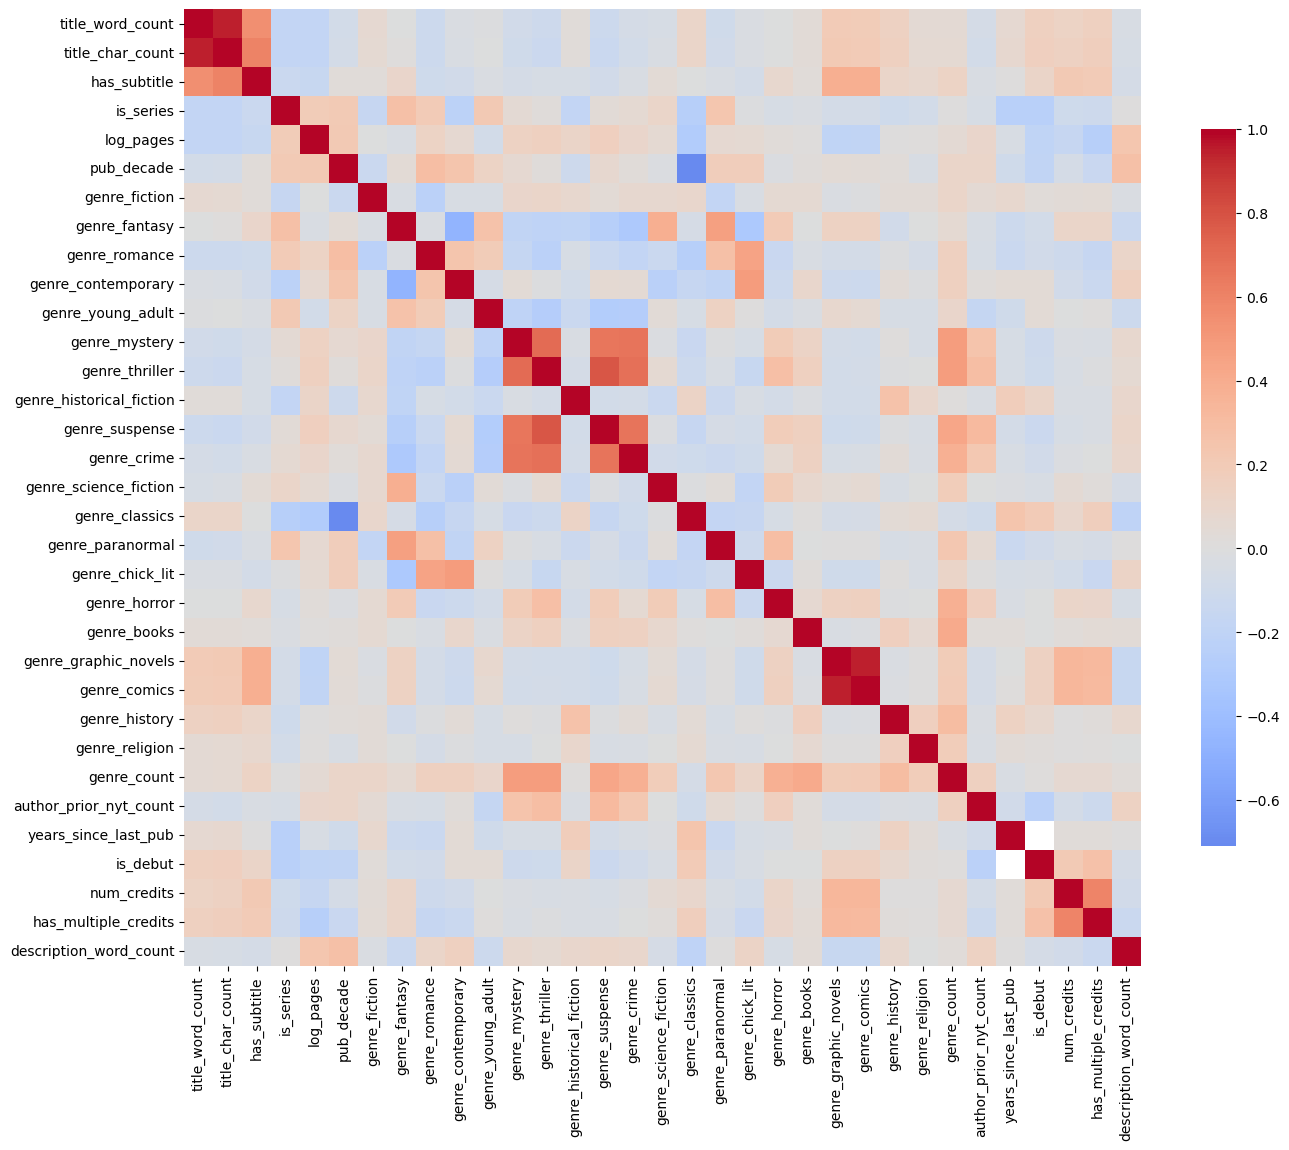

Feature pairs with |r| > 0.5:
title_word_count             <-> title_char_count              r=+0.945
genre_comics                 <-> genre_graphic_novels          r=+0.940
genre_suspense               <-> genre_thriller                r=+0.782
pub_decade                   <-> genre_classics                r=-0.709
genre_mystery                <-> genre_thriller                r=+0.706
genre_crime                  <-> genre_thriller                r=+0.683
genre_crime                  <-> genre_suspense                r=+0.668
genre_mystery                <-> genre_crime                   r=+0.662
genre_suspense               <-> genre_mystery                 r=+0.656
title_char_count             <-> has_subtitle                  r=+0.605
num_credits                  <-> has_multiple_credits          r=+0.594
has_subtitle                 <-> title_word_count              r=+0.551


In [14]:
# ── Correlation heatmap on the final design matrix ──────────────────────────
corr = X.drop(columns=['gb_id']).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, square=True,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.7})
plt.tight_layout()
plt.savefig('../results/feature_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag high-correlation pairs — IMPORTANT: use abs() only to select which
# pairs are "strong", but always display the actual SIGNED value, not the
# absolute value, or you'll misreport negative correlations as positive.
corr_abs = corr.abs()
pairs_abs = corr_abs.where(~np.eye(len(corr_abs), dtype=bool)).stack()
high = pairs_abs[pairs_abs > 0.5].sort_values(ascending=False)

seen = set()
print('Feature pairs with |r| > 0.5:')
for (a, b), _ in high.items():
    key = tuple(sorted([a, b]))
    if key in seen:
        continue
    seen.add(key)
    signed_r = corr.loc[a, b]
    print(f'{a:28s} <-> {b:28s}  r={signed_r:+.3f}')

In [15]:
X.head(3)

,gb_id,title_word_count,title_char_count,has_subtitle,is_series,log_pages,pub_decade,genre_fiction,genre_fantasy,genre_romance,...,genre_comics,genre_history,genre_religion,genre_count,author_prior_nyt_count,years_since_last_pub,is_debut,num_credits,has_multiple_credits,description_word_count
0,0,3,16,False,True,5.926926,2000,True,True,True,...,False,False,False,5,0,1.0,False,1,False,147
1,1,6,37,False,True,5.736572,1990,True,True,False,...,False,False,False,4,0,NaN,True,2,True,220
2,2,1,8,False,True,6.218600,2000,True,True,True,...,False,False,False,5,0,NaN,True,1,False,55


## 9. Finalize & save design matrix 

In [16]:
# Drop title_char_count due to high correlation with title_word_count (>0.9)
X_final = drop_correlated_features(X, threshold=0.9, exclude=['gb_id'])
print(X_final.shape)

Dropping 'title_char_count' (r=0.945 with 'title_word_count')
Dropping 'genre_comics' (r=0.940 with 'genre_graphic_novels')
(7983, 32)


In [17]:
X_final.head(3)

,gb_id,title_word_count,has_subtitle,is_series,log_pages,pub_decade,genre_fiction,genre_fantasy,genre_romance,genre_contemporary,...,genre_graphic_novels,genre_history,genre_religion,genre_count,author_prior_nyt_count,years_since_last_pub,is_debut,num_credits,has_multiple_credits,description_word_count
0,0,3,False,True,5.926926,2000,True,True,True,False,...,False,False,False,5,0,1.0,False,1,False,147
1,1,6,False,True,5.736572,1990,True,True,False,False,...,False,False,False,4,0,NaN,True,2,True,220
2,2,1,False,True,6.218600,2000,True,True,True,False,...,False,False,False,5,0,NaN,True,1,False,55


In [18]:
from pathlib import Path

# notebooks/ -> repo root is one level up
DATA_DIR    = Path('..') / 'data'
DERIVED_DIR = Path('..') / 'derived'
DATA_DIR.mkdir(parents=True, exist_ok=True)
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

parquet_path = DERIVED_DIR / 'features.parquet'
csv_path     = DATA_DIR / 'features.csv'

X_final.to_parquet(parquet_path, index=False)
X_final.to_csv(csv_path, index=False)

print(f'Saved parquet ({X_final.shape[0]:,} rows, {X_final.shape[1]} cols)')
print(f'Saved csv ({X_final.shape[0]:,} rows, {X_final.shape[1]} cols)')

Saved parquet (7,983 rows, 32 cols)
Saved csv (7,983 rows, 32 cols)


## Summary

- **32 features saved** to `data/features.parquet` (+ CSV copy) after dropping two collinear
  pairs: `title_char_count` (r=0.945 with `title_word_count`) and, newly, `genre_comics`
  (r=0.940 with `genre_graphic_novels` — this pair only entered the top-20 genre list after
  non-fiction books were filtered out, which freed up room previously held by
  biography/history/memoir tags).
- **Strongest signal found:** genre (suspense/thriller/crime/mystery run
  2x the base rate), `is_series` (standalone 20.4% vs. series 9.1% —
  though see label-scope caveat above), `title_word_count` (short titles
  ≤2 words: 32.3% vs. 15.1% overall).
- **Modest but real signal:** `description_word_count`, `desc_compound`
  (sentiment; explored, not yet in saved matrix), `years_since_last_pub`.
- **Genre collinearity is real but kept** — overlapping Goodreads tags
  (r=0.66–0.79 within the suspense/thriller/mystery/crime family), not
  pruned since they're distinct concepts; regularization in `03`/tree
  splits in `04` handle this natively.

**Next:** `03_baseline_model.ipynb` — logistic regression on this
structural matrix, year-2010 split (per `01`), `class_weight='balanced'`.